# **Portfolio Forecast Demo: Full Report**

Forecasts the next 100 trading days of one stock with all three simulators, compares them, and typesets the results as a PDF report.

1. Download 10 years of daily AAPL prices.
2. Simulate 1,000 paths with non-parametric, parametric and regime-switching Monte Carlo.
3. Compare the methods' paths and statistical reports.
4. Compile a PDF report of the parametric and regime-switching results (needs LaTeX).

## **Imports**

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

from portfolio_forecast.forecast import nonparametric_monte_carlo, parametric_monte_carlo, regime_switching_monte_carlo
from portfolio_forecast.performance import statistical_report
from portfolio_forecast.plotting import plot_path_comparison, plot_simulated_paths
from portfolio_forecast.reporting import compile_statistical_reports
from portfolio_forecast.utils import next_trading_dates

## **Obtaining Example Data**

In [21]:
# Ten years of daily AAPL bars from Yahoo Finance, adjusted for splits and dividends
df_full = yf.download('AAPL', period='10y', auto_adjust=True, progress=False)

### **Reformatting the Example Data as a Single-Column DataFrame**

Index: Date / Datetime

Column: Portfolio Value / Prices

In [22]:
# Taking closing prices as a single-column dataframe; dropna removes a trailing
# row with no close, which Yahoo can return while a session is incomplete
prices = df_full['Close'].dropna()
prices

Ticker,AAPL
Date,
2016-09-19,25.974119
2016-09-20,25.971821
2016-09-21,25.967260
2016-09-22,26.211946
2016-09-23,25.775156
...,...
2026-09-14,333.079987
2026-09-15,331.339996
2026-09-16,332.410004


## **Example Simulations**

In [23]:
# Dates for the plots: the last historical close (each path's starting value)
# followed by the next 100 trading days, matching sim_length=100 below
sim_dates = prices.index[-1:].append(next_trading_dates(prices.index, 100))

### **Example 1: Non-parametric Monte Carlo**

In [24]:
# A seed (an int or a seeded Generator) makes the paths reproducible
# Resampling historical returns with replacement
sims_nonparametric = nonparametric_monte_carlo(prices, sim_length=100, n_sims=1000,
                                               random_state=np.random.default_rng(42))

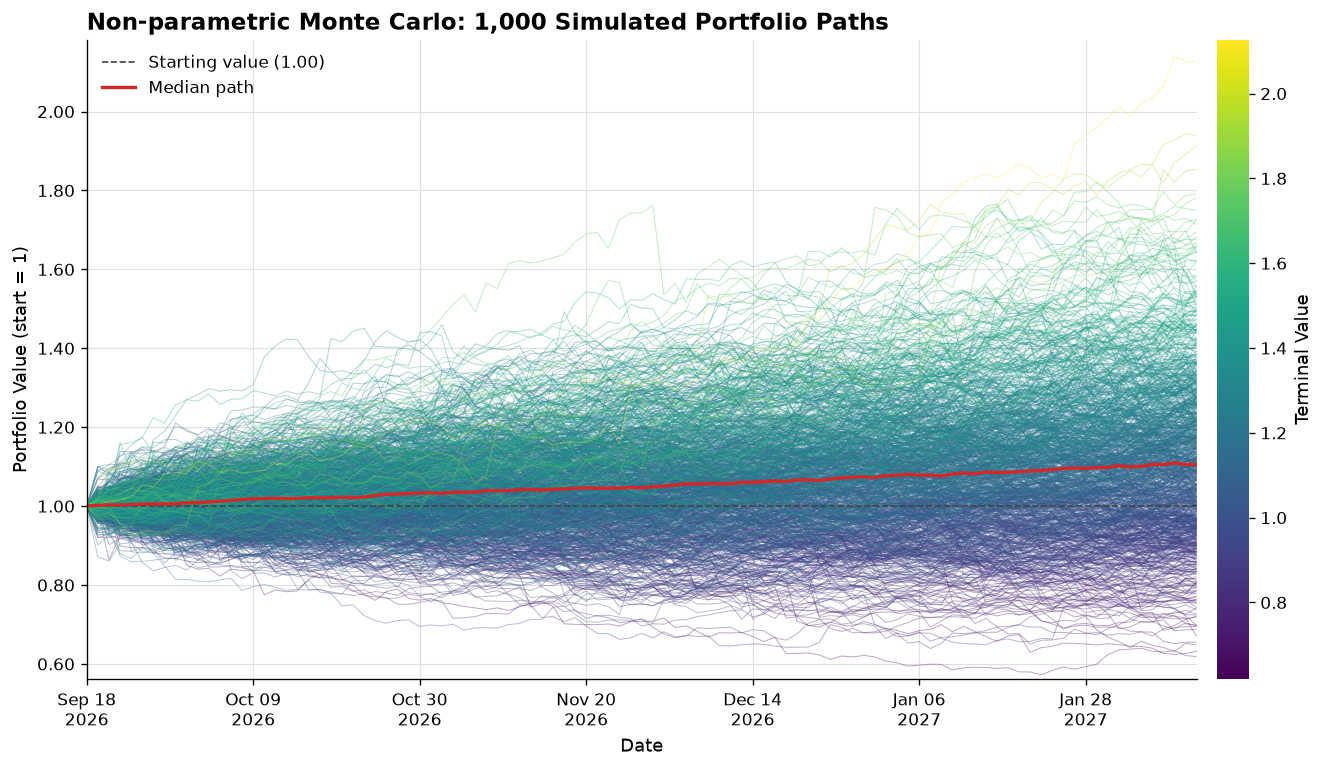

In [25]:
# Fan chart of the paths, colored by where each one ends
fig, ax = plot_simulated_paths(sims_nonparametric, method='Non-parametric Monte Carlo', dates=sim_dates)
plt.show()

### **Example 2: Parametric Monte Carlo**

In [26]:
# distribution=None fits normal, t, and Johnson SU and uses the lowest AIC;
# return_fit=True also returns the chosen distribution, its parameters and every AIC
sims_parametric, fit_parametric = parametric_monte_carlo(prices, distribution=None, sim_length=100,
                                                         n_sims=1000, random_state=np.random.default_rng(42),
                                                         return_fit=True)

      norm AIC: -12,962.07
         t AIC: -13,481.72
 johnsonsu AIC: -13,487.48
Selected: johnsonsu


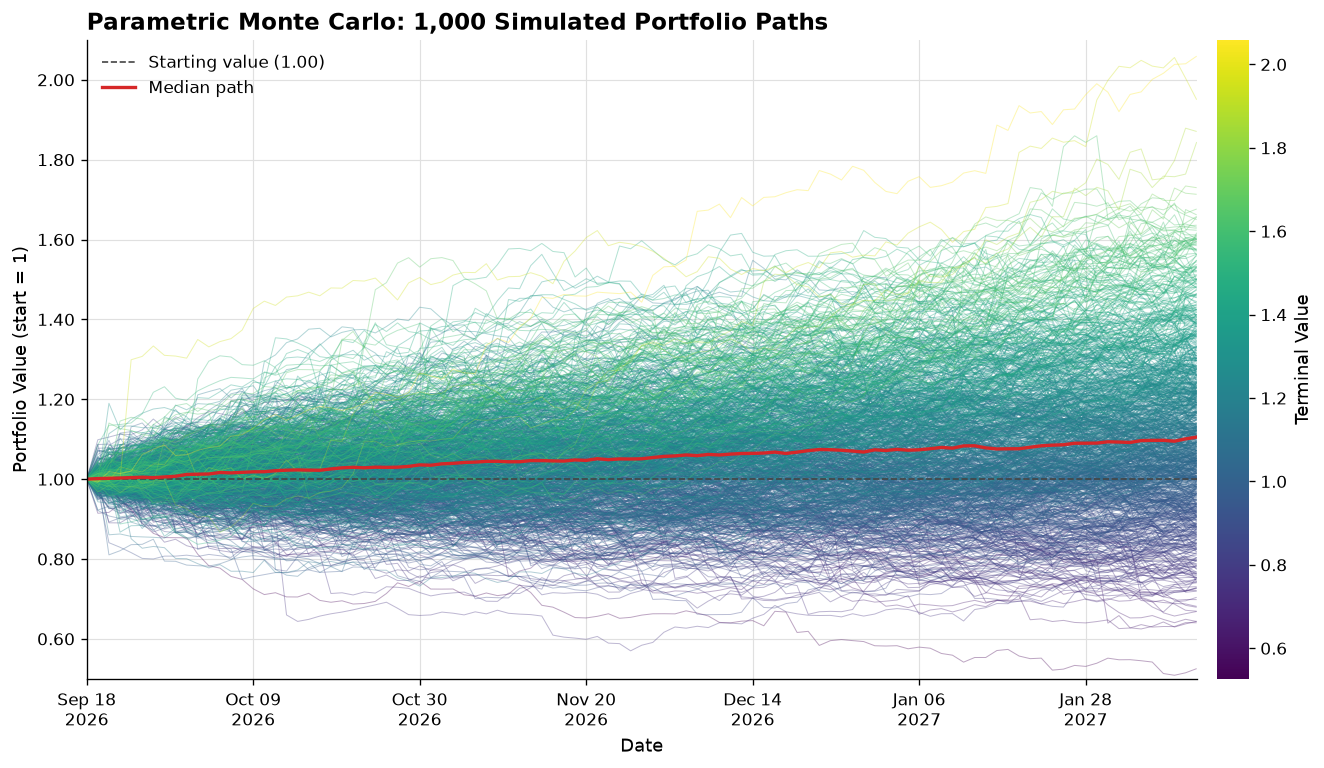

In [27]:
# Fan chart of the paths, colored by where each one ends
fig, ax = plot_simulated_paths(sims_parametric, method='Parametric Monte Carlo', dates=sim_dates)
plt.show()

### **Example 3: Regime-Switching Monte Carlo**

In [28]:
# n_regimes=None fits 1, 2, and 3 regimes and uses the lowest BIC;
# bootstrap=True would resample each regime's historical returns instead of drawing from a normal
# return_fit=True also returns the regime count, each count's BIC and a table of the regimes
sims_regime, fit_regime = regime_switching_monte_carlo(prices, n_regimes=None, bootstrap=False,
                                                       sim_length=100, n_sims=1000,
                                                       random_state=np.random.default_rng(42),
                                                       return_fit=True)
fit_regime['Regimes']

1 regime(s) BIC: -12,954.73
2 regime(s) BIC: -13,549.87
3 regime(s) BIC: -13,607.90
Selected: 3 regime(s)
Regime 0: mean +0.1790%, vol 0.9339%, expected duration 15.3 periods
Regime 1: mean +0.0932%, vol 1.9743%, expected duration 13.3 periods
Regime 2: mean -0.5659%, vol 4.6658%, expected duration 8.6 periods


,Mean,Volatility,Expected Duration,Current Probability
Regime,,,,
0,0.001790,0.009339,15.283481,0.724419
1,0.000932,0.019743,13.301560,0.273297
2,-0.005659,0.046658,8.613155,0.002284


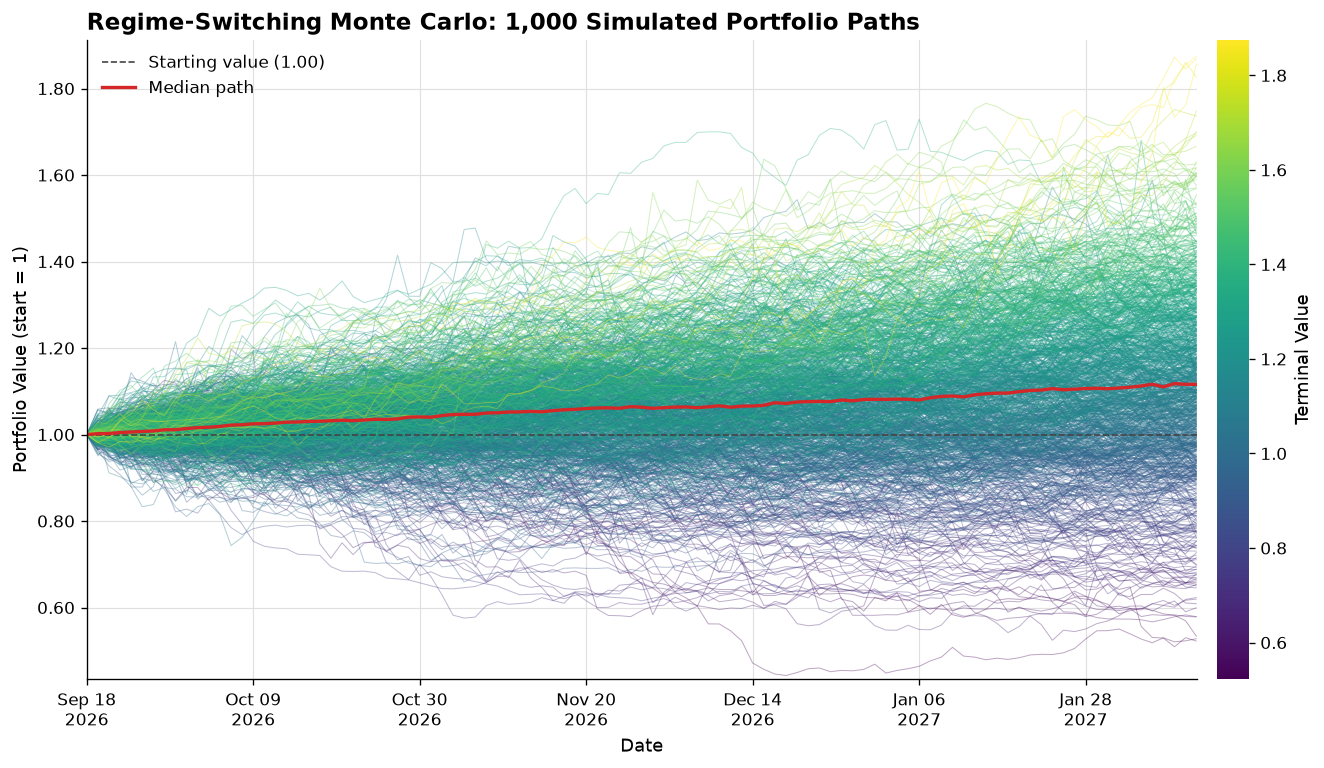

In [29]:
# Fan chart of the paths, colored by where each one ends
fig, ax = plot_simulated_paths(sims_regime, method='Regime-Switching Monte Carlo', dates=sim_dates)
plt.show()

### **Comparison: All Methods Side by Side**

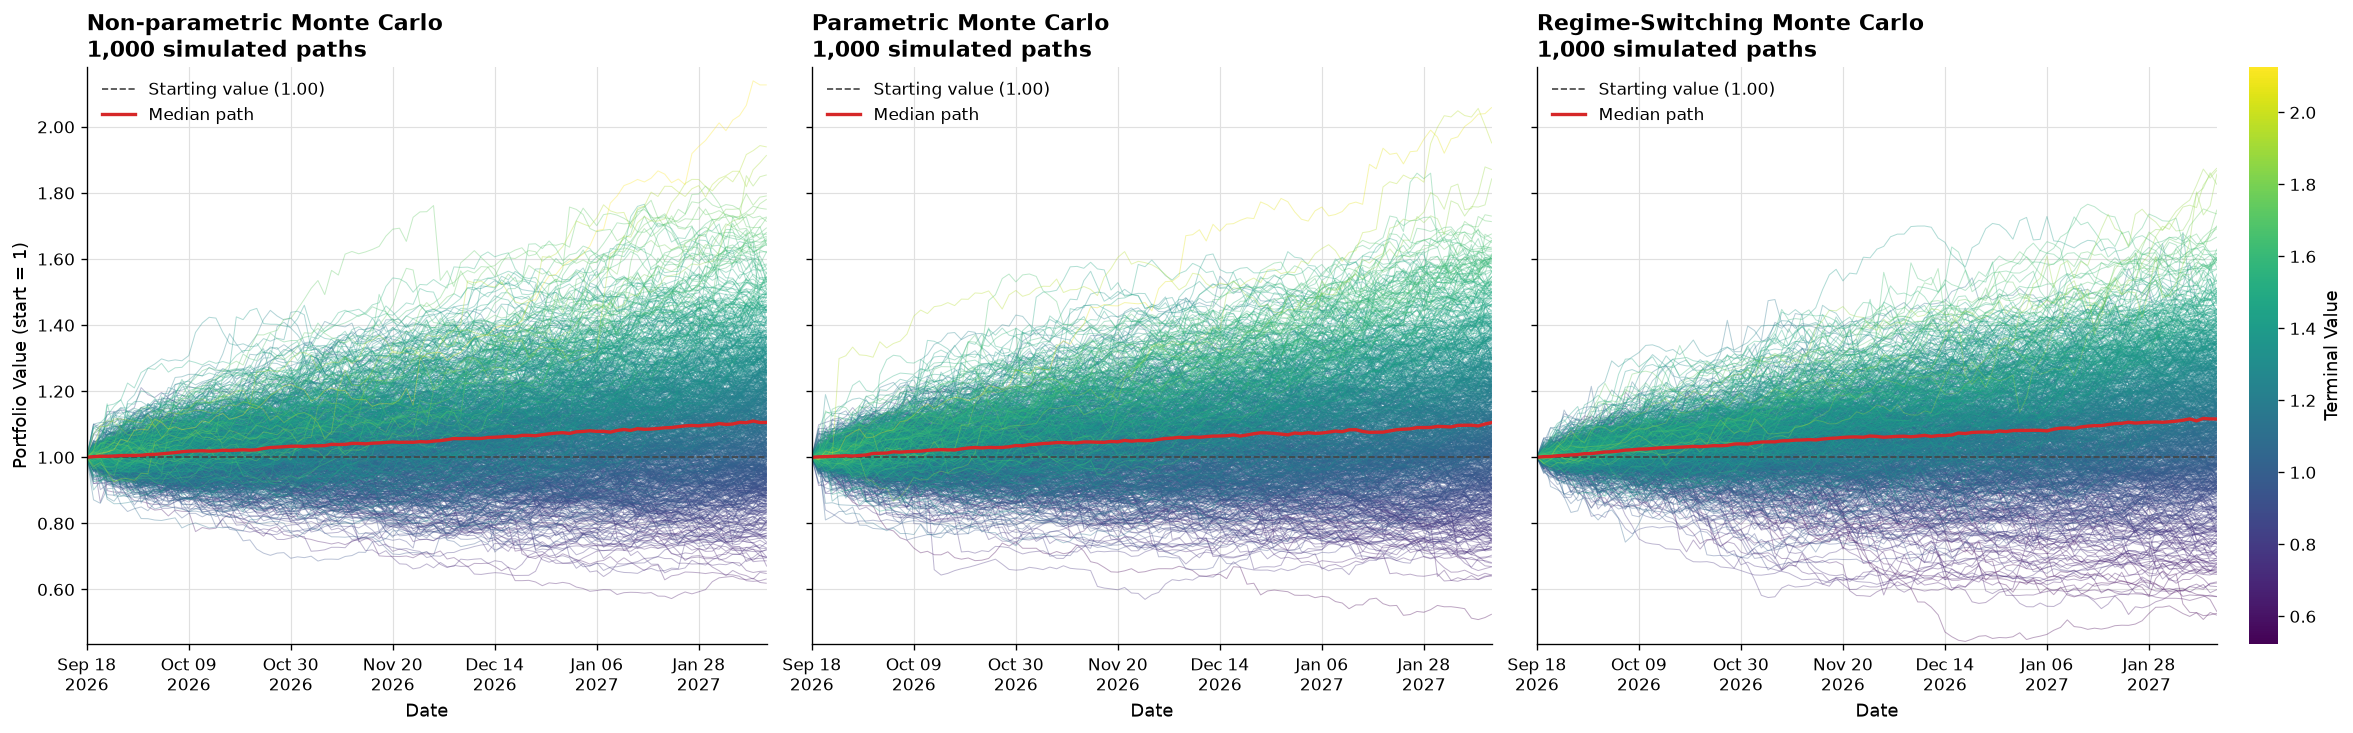

In [30]:
# All three methods side by side, on a shared y-axis and color scale
fig, axes = plot_path_comparison({
    'Non-parametric Monte Carlo': sims_nonparametric,
    'Parametric Monte Carlo': sims_parametric,
    'Regime-Switching Monte Carlo': sims_regime,
}, dates=sim_dates)
plt.show()

### **Statistical Reports**

In [31]:
# Each metric's median and 95% interval across the simulated paths, per method
for method, sims in {
    'Non-parametric Monte Carlo': sims_nonparametric,
    'Parametric Monte Carlo': sims_parametric,
    'Regime-Switching Monte Carlo': sims_regime,
}.items():
    print(f'{method} Report')
    report = statistical_report(sims, interval='1 day', confidence=0.95, display=True)

Non-parametric Monte Carlo Report

                     SIMULATED PORTFOLIO STATISTICAL REPORT                     
--------------------------------------------------------------------------------
  Simulated Paths      : 1,000
  Horizon              :   100 periods  (0.40 years)
                                    RETURNS                                     
--------------------------------------------------------------------------------
                               Mean       Median                   95% interval
--------------------------------------------------------------------------------
  Final Bankroll       :       1.13         1.11                   [0.78, 1.58]
  Total Return         :     12.61%       10.57%              [-22.27%, 58.30%]
  CAGR                 :     43.85%       28.83%             [-47.00%, 218.21%]
                                      RISK                                      
---------------------------------------------------------------------------

## **PDF Report**

`compile_statistical_reports` typesets statistical reports and figures as a PDF with LaTeX (it needs `pdflatex` installed). It takes a dictionary with a title, an introduction and one entry per report, each with a description, the results of `statistical_report` and any figures with captions. The PDF is saved to `Reporting/` in the working directory, and no other files are left behind.

This example reports on the parametric and regime-switching simulations.

In [13]:
# Statistical reports for the two methods; the simulated dates add the calendar span
results_parametric = statistical_report(sims_parametric, interval='1 day', dates=sim_dates)
results_regime = statistical_report(sims_regime, interval='1 day', dates=sim_dates)

# Fan charts to embed in the PDF, plus both methods side by side
fig_parametric, _ = plot_simulated_paths(sims_parametric, method='Parametric Monte Carlo', dates=sim_dates)
fig_regime, _ = plot_simulated_paths(sims_regime, method='Regime-Switching Monte Carlo', dates=sim_dates)
fig_comparison, _ = plot_path_comparison({
    'Parametric Monte Carlo': sims_parametric,
    'Regime-Switching Monte Carlo': sims_regime,
}, dates=sim_dates)
# Close them so they are not also drawn here; a closed figure can still be saved
plt.close('all')


def change(r):
    """A return as words, e.g. 0.105 -> '10.5% higher'."""
    return f"{abs(r):.1%} {'higher' if r >= 0 else 'lower'}"


def outcome_summary(results):
    """One sentence on where the paths end, from a statistical_report result."""
    total = results['Returns'].loc['Total Return']
    loss = results['Tail Risk']['Probability of Loss']
    return (f"The median path ends {change(total['Median'])} after 100 trading days; 95% of paths end "
            f"between {change(total['Lower'])} and {change(total['Upper'])}, and {loss:.0%} end below "
            "the last close.")


DISTRIBUTION_NAMES = {'norm': 'normal', 't': "Student's t", 'johnsonsu': 'Johnson SU'}


def distribution_summary(fit):
    """Which distribution the AIC chose and by how much, from parametric_monte_carlo's fit."""
    (chosen, best), *others = fit['Candidates'].items()
    gaps = ' and '.join(f"{aic - best:,.1f} below the {DISTRIBUTION_NAMES[name]}" for name, aic in others)
    return f"The {DISTRIBUTION_NAMES[chosen]} distribution had the lowest AIC, {gaps}, so it was used."


REGIME_LABELS = {1: ['single'], 2: ['calm', 'turbulent'], 3: ['calm', 'moderate', 'turbulent']}
COUNT_WORDS = {1: 'one', 2: 'two', 3: 'three'}


def regime_summary(fit):
    """The regimes the BIC chose, calmest first, from regime_switching_monte_carlo's fit."""
    count, regimes = fit['Regime Count'], fit['Regimes']
    labels = REGIME_LABELS[count]
    parts = []
    for label, (_, row) in zip(labels, regimes.iterrows(), strict=True):
        part = (f"a {label} regime with {row['Volatility']:.1%} daily volatility and a "
                f"{abs(row['Mean']):.2%} average daily {'gain' if row['Mean'] >= 0 else 'loss'}")
        if count > 1:
            part += f", lasting about {row['Expected Duration']:.0f} days at a time"
        parts.append(part)
    listed = parts[0] if count == 1 else '; '.join(parts[:-1]) + '; and ' + parts[-1]
    likely = regimes['Current Probability'].idxmax()
    return (f"The BIC selected {COUNT_WORDS[count]} regime{'s' if count > 1 else ''} of daily log returns: "
            f"{listed}. At the last close, the {labels[likely]} regime is the most likely, with a "
            f"probability of {regimes['Current Probability'].max():.0%}.")

### **Assembling the Report Dictionary**

Reports and figures appear in the PDF in dictionary order. Text is printed literally, so characters such as `%` and `&` need no escaping, and a blank line starts a new paragraph. Each figure's optional `Width` sets its size as a share of the text width.

In [18]:
# Each figure's width as a share of the text width (1.0, the default, is full width)
figure_width = 0.85

fan_chart_caption = ('1,000 simulated paths of the next 100 trading days, colored by terminal value. '
                     'The red line is the median path; the dashed line is the starting value, the last close.')

report_spec = {
    'Title': 'AAPL 100-Day Price Outlook',
    'Introduction': (
        f"This report simulates the next 100 trading days of Apple (AAPL) from {len(prices):,} daily closes, "
        f"{prices.index[0]:%B %Y} to {prices.index[-1]:%B %Y}, adjusted for splits and dividends. "
        "Each method generates 1,000 price paths, and every figure is a multiple of the last close: "
        "1.10 means the price ended 10% higher.\n\n"
        "Two methods are compared. Parametric Monte Carlo draws each day's return independently from a "
        "fitted distribution; regime-switching Monte Carlo lets volatility move between calm and turbulent "
        "regimes. Intervals cover the central 95% of simulated outcomes."
    ),
    'Reports': {
        'Parametric Monte Carlo': {
            'Description': (
                "A normal, a Student's t and a Johnson SU distribution are fitted to the daily returns by "
                "maximum likelihood, and the one with the lowest AIC is used. Each path compounds 100 "
                "independent draws from it, so fat tails carry over if the chosen distribution has them, "
                "but volatility clustering does not. " + distribution_summary(fit_parametric)
                + "\n\n" + outcome_summary(results_parametric)
            ),
            'Results': results_parametric,
            'Figures': {
                'Paths': {'Image': fig_parametric, 'Caption': 'Parametric Monte Carlo: ' + fan_chart_caption,
                          'Width': figure_width},
            },
        },
        'Regime-Switching Monte Carlo': {
            'Description': (
                "A Gaussian hidden Markov model is fitted to the daily log returns with 1, 2 and 3 regimes, "
                "and the count with the lowest BIC is used. Each regime has its own mean and volatility, and "
                "paths move between regimes by the fitted transition probabilities, so turbulent days "
                "cluster together as they do in real markets.\n\n" + regime_summary(fit_regime)
                + "\n\n" + outcome_summary(results_regime)
            ),
            'Results': results_regime,
            'Figures': {
                'Paths': {'Image': fig_regime, 'Caption': 'Regime-switching Monte Carlo: ' + fan_chart_caption,
                          'Width': figure_width},
                'Comparison': {
                    'Image': fig_comparison,
                    'Caption': ('Parametric (left) and regime-switching (right) paths on a shared y-axis and '
                                'color scale, so the spread of outcomes compares directly.'),
                    'Width': 1,
                },
            },
        },
    },
}

In [19]:
# Typeset the PDF into Reporting/ in the working directory;
# table_of_contents=True would also list the reports with their page numbers
pdf = compile_statistical_reports(report_spec, table_of_contents=False)
print(f'Saved {pdf.relative_to(Path.cwd())}')

Saved Reporting/AAPL_100_Day_Price_Outlook.pdf
